# ***SCRAPING DATA***

###Tahap awal adalah pengambilan data (scraping) dari Play Store menggunakan pustaka seperti BeautifulSoup dan google-play-scraper.

In [ ]:
#google-play-scraper digunakan untuk mengambil data dari Google Play Store secara otomatis (web scraping), tanpa perlu API resmi dari Google.
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.4 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import app, reviews #app → Digunakan untuk mengambil informasi detail aplikasi berdasarkan ID aplikasi.
#reviews → Digunakan untuk mengambil ulasan pengguna dari aplikasi tertentu.
import pandas as pd #Fungsi: Mengimpor library pandas, yang digunakan untuk manipulasi dan analisis data dalam bentuk tabel (DataFrame dan Series).
#as pd: Memberi alias pd agar lebih ringkas saat digunakan dalam kode.
import datetime #Fungsi: Mengimpor modul datetime, yang digunakan untuk bekerja dengan tanggal dan waktu.

google_play_scraper: Library ini digunakan untuk mengambil informasi aplikasi dan ulasan dari Google Play Store.
pandas: Digunakan untuk bekerja dengan data dalam format DataFrame.
datetime: Digunakan untuk menentukan rentang waktu (start_date dan end_date).

In [ ]:
import requests
from bs4 import BeautifulSoup
import csv
import time

BASE_URL = "https://www.liputan6.com/health?page="
TARGET_COUNT = 5000   # 5000 data.
headers = {"User-Agent": "Mozilla/5.0"}

# =====================
# SCRAPE DETAIL ARTIKEL
# =====================
def scrape_detail(url):
    try:
        r = requests.get(url, headers=headers, timeout=10)
        r.raise_for_status()
    except:
        print("   Gagal akses detail:", url)
        return "", "", "", ""

    soup = BeautifulSoup(r.text, "html.parser")

    # Penulis
    author = soup.select_one("a.article-author__name")
    author = author.get_text(strip=True) if author else ""

    # Tags
    tags = soup.select("a.articles--keywords--item")
    tags = ", ".join([t.get_text(strip=True) for t in tags]) if tags else ""

    # Ringkasan
    summary = soup.select_one("div.article-content-body__item-content > p")
    summary = summary.get_text(strip=True) if summary else ""

    # Isi artikel (gabungkan semua <p>)
    paragraphs = soup.select("div.article-content-body__item-content p")
    content = "\n".join([p.get_text(strip=True) for p in paragraphs]) if paragraphs else ""

    return author, tags, summary, content


# =====================
# SCRAPE LIST ARTICLE
# =====================
def scrape_page(page):
    url = BASE_URL + str(page)
    try:
        r = requests.get(url, headers=headers, timeout=10)
        r.raise_for_status()
    except:
        print("Gagal akses halaman", page)
        return []

    soup = BeautifulSoup(r.text, "html.parser")
    articles = soup.select("article.articles--iridescent-list--item")

    results = []

    for a in articles:
        title_tag = a.select_one("h4.articles--iridescent-list--text-item__title a")
        if not title_tag:
            continue

        title = title_tag.get_text(strip=True)
        link = title_tag.get("href")

        time_tag = a.select_one("span.articles--iridescent-list--text-item__datetime")
        tanggal = time_tag.get_text(strip=True) if time_tag else ""

        # SCRAPE DETAIL TIAP ARTIKEL
        print("   Ambil detail:", title)
        author, tags, summary, content = scrape_detail(link)

        results.append({
            "judul": title,
            "link": link,
            "tanggal": tanggal,
            "penulis": author,
            "tag": tags,
            "ringkasan": summary,
            "isi_artikel": content
        })

        time.sleep(0.5)

    return results


# =====================
# MAIN
# =====================
def main():
    all_data = []
    page = 1

    print("Mulai scraping Liputan6 Health...")

    while len(all_data) < TARGET_COUNT:
        print(f"Scraping halaman {page}...")

        batch = scrape_page(page)
        if not batch:
            print("Tidak ada data di halaman ini, stop.")
            break

        all_data.extend(batch)
        print("Total terkumpul:", len(all_data))

        page += 1
        time.sleep(1)

    all_data = all_data[:TARGET_COUNT]

    with open("liputan6_health_lengkap.csv", "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=[
            "judul", "link", "tanggal", "penulis", "tag", "ringkasan", "isi_artikel"
        ])
        writer.writeheader()
        writer.writerows(all_data)

    print("Selesai! File disimpan sebagai liputan6_health_lengkap.csv")


if __name__ == "__main__":
    main()


Streaming output truncated to the last 5000 lines.
   Ambil detail: Rahasia Kulit Glowing Aktris Zhao Lusi, Andalkan Pijat Meridian yang Bisa Perlancar Pereda...
   Ambil detail: Wanmono, Sup Jepang yang Buktikan Gurih Umami Tak Harus Tinggi Garam
   Ambil detail: Uji Klinis Fase I Vaksin TB Inhalasi Dimulai, Prof. Erlina Burhan Memimpin Langsung Peneli...
   Ambil detail: IDEC 2025: Percepatan Inovasi untuk Ketahanan Kesehatan Gigi dari Kota hingga Daerah Terpe...
   Ambil detail: Wamenkes Benny Tegaskan Peran Vaksin TB Inhalasi untuk Indonesia Bebas TBC 2030
   Ambil detail: Kasus Gigi dan Mulut Tertinggi Kedua Setelah Hipertensi, Pakar Peringatkan Dampaknya pada ...
   Ambil detail: Wagyu Asli Jepang dan Inovasi Kuliner Indonesia yang Menggoda Lidah, Dijamin Tidak Bikin G...
   Ambil detail: Ahli: Risiko Diabetes Anak Bisa Naik 6 Kali Lipat Jika Kedua Orang Tua Mengidap Penyakit y...
   Ambil detail: Diabetes Genetik hingga Obesitas, Ahli Ungkap Penyebab Lonjakan Kasus pada Gen Z da

In [ ]:
import csv

def export_to_csv(data, file_name='liputan6_health_lengkap.csv'):
    if data:
        fieldnames = ["judul", "link", "tanggal", "penulis", "tag", "ringkasan", "isi_artikel"]

        with open(file_name, mode='w', newline='', encoding='utf-8') as csv_file:
            writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(data)

        print(f"Data berhasil diekspor ke '{file_name}'")
    else:
        print("Tidak ada data untuk diekspor.")

In [ ]:
import pandas as pd

data = pd.read_csv("liputan6_health_lengkap.csv", encoding="utf-8")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   judul        5000 non-null   object 
 1   link         5000 non-null   object 
 2   tanggal      5000 non-null   object 
 3   penulis      0 non-null      float64
 4   tag          0 non-null      float64
 5   ringkasan    5000 non-null   object 
 6   isi_artikel  5000 non-null   object 
dtypes: float64(2), object(5)
memory usage: 273.6+ KB


In [ ]:
data.head(10) #untuk menampilkan 5 baris pertama dari DataFrame.

,judul,link,tanggal,penulis,tag,ringkasan,isi_artikel
0,"Paramount Color Walk 2025 Siap Digelar, Ajang ...",https://www.liputan6.com/health/read/6212617/p...,15 Nov 2025 18:00,NaN,NaN,"Liputan6.com, TangerangAjangjalan sehatParamou...","Liputan6.com, TangerangAjangjalan sehatParamou..."
1,Cara Chef Junichi Sajikan Kuliner Jepang Halal...,https://www.liputan6.com/health/read/6212178/c...,15 Nov 2025 16:00,NaN,NaN,"Liputan6.com, Jakarta -Mencarikuliner Jepangya...","Liputan6.com, Jakarta -Mencarikuliner Jepangya..."
2,"Rahasia Kulit Glowing Aktris Zhao Lusi, Andalk...",https://www.liputan6.com/health/read/6211902/r...,15 Nov 2025 14:00,NaN,NaN,"Liputan6.com, JakartaMasih mencari cara untuk ...","Liputan6.com, JakartaMasih mencari cara untuk ..."
3,"Wanmono, Sup Jepang yang Buktikan Gurih Umami ...",https://www.liputan6.com/health/read/6211990/w...,15 Nov 2025 12:00,NaN,NaN,"Liputan6.com, Jakarta -Dalam tradisikuliner Je...","Liputan6.com, Jakarta -Dalam tradisikuliner Je..."
4,"Uji Klinis Fase I Vaksin TB Inhalasi Dimulai, ...",https://www.liputan6.com/health/read/6212013/u...,15 Nov 2025 10:00,NaN,NaN,"Liputan6.com, Jakarta -Indonesia resmi memasuk...","Liputan6.com, Jakarta -Indonesia resmi memasuk..."
5,IDEC 2025: Percepatan Inovasi untuk Ketahanan ...,https://www.liputan6.com/health/read/6212186/i...,15 Nov 2025 09:00,NaN,NaN,"Liputan6.com, Jakarta -Ketahanan sistemkesehat...","Liputan6.com, Jakarta -Ketahanan sistemkesehat..."
6,Wamenkes Benny Tegaskan Peran Vaksin TB Inhala...,https://www.liputan6.com/health/read/6211969/w...,15 Nov 2025 08:00,NaN,NaN,"Liputan6.com, Jakarta -Wakil Menteri Kesehatan...","Liputan6.com, Jakarta -Wakil Menteri Kesehatan..."
7,Kasus Gigi dan Mulut Tertinggi Kedua Setelah H...,https://www.liputan6.com/health/read/6212148/k...,15 Nov 2025 07:00,NaN,NaN,"Liputan6.com, Jakarta -Masalah kesehatangigida...","Liputan6.com, Jakarta -Masalah kesehatangigida..."
8,Wagyu Asli Jepang dan Inovasi Kuliner Indonesi...,https://www.liputan6.com/health/read/6211314/w...,15 Nov 2025 06:00,NaN,NaN,"Liputan6.com, Jakarta -Popularitaswagyukian me...","Liputan6.com, Jakarta -Popularitaswagyukian me..."
9,Ahli: Risiko Diabetes Anak Bisa Naik 6 Kali Li...,https://www.liputan6.com/health/read/6211344/a...,14 Nov 2025 21:00,NaN,NaN,"Liputan6.com, Jakarta -Risikodiabetespadaanakt...","Liputan6.com, Jakarta -Risikodiabetespadaanakt..."


# ***PREPROCESSING DATA***

###Tahapan ini bertujuan untuk membersihkan dan menyiapkan data teks agar mudah dianalisis oleh sistem.

In [ ]:
import pandas as pd

data = pd.read_csv("liputan6_health_lengkap.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   judul        5000 non-null   object 
 1   link         5000 non-null   object 
 2   tanggal      5000 non-null   object 
 3   penulis      0 non-null      float64
 4   tag          0 non-null      float64
 5   ringkasan    5000 non-null   object 
 6   isi_artikel  5000 non-null   object 
dtypes: float64(2), object(5)
memory usage: 273.6+ KB


In [ ]:
data.head(10)

,judul,link,tanggal,penulis,tag,ringkasan,isi_artikel
0,"Paramount Color Walk 2025 Siap Digelar, Ajang ...",https://www.liputan6.com/health/read/6212617/p...,15 Nov 2025 18:00,NaN,NaN,"Liputan6.com, TangerangAjangjalan sehatParamou...","Liputan6.com, TangerangAjangjalan sehatParamou..."
1,Cara Chef Junichi Sajikan Kuliner Jepang Halal...,https://www.liputan6.com/health/read/6212178/c...,15 Nov 2025 16:00,NaN,NaN,"Liputan6.com, Jakarta -Mencarikuliner Jepangya...","Liputan6.com, Jakarta -Mencarikuliner Jepangya..."
2,"Rahasia Kulit Glowing Aktris Zhao Lusi, Andalk...",https://www.liputan6.com/health/read/6211902/r...,15 Nov 2025 14:00,NaN,NaN,"Liputan6.com, JakartaMasih mencari cara untuk ...","Liputan6.com, JakartaMasih mencari cara untuk ..."
3,"Wanmono, Sup Jepang yang Buktikan Gurih Umami ...",https://www.liputan6.com/health/read/6211990/w...,15 Nov 2025 12:00,NaN,NaN,"Liputan6.com, Jakarta -Dalam tradisikuliner Je...","Liputan6.com, Jakarta -Dalam tradisikuliner Je..."
4,"Uji Klinis Fase I Vaksin TB Inhalasi Dimulai, ...",https://www.liputan6.com/health/read/6212013/u...,15 Nov 2025 10:00,NaN,NaN,"Liputan6.com, Jakarta -Indonesia resmi memasuk...","Liputan6.com, Jakarta -Indonesia resmi memasuk..."
5,IDEC 2025: Percepatan Inovasi untuk Ketahanan ...,https://www.liputan6.com/health/read/6212186/i...,15 Nov 2025 09:00,NaN,NaN,"Liputan6.com, Jakarta -Ketahanan sistemkesehat...","Liputan6.com, Jakarta -Ketahanan sistemkesehat..."
6,Wamenkes Benny Tegaskan Peran Vaksin TB Inhala...,https://www.liputan6.com/health/read/6211969/w...,15 Nov 2025 08:00,NaN,NaN,"Liputan6.com, Jakarta -Wakil Menteri Kesehatan...","Liputan6.com, Jakarta -Wakil Menteri Kesehatan..."
7,Kasus Gigi dan Mulut Tertinggi Kedua Setelah H...,https://www.liputan6.com/health/read/6212148/k...,15 Nov 2025 07:00,NaN,NaN,"Liputan6.com, Jakarta -Masalah kesehatangigida...","Liputan6.com, Jakarta -Masalah kesehatangigida..."
8,Wagyu Asli Jepang dan Inovasi Kuliner Indonesi...,https://www.liputan6.com/health/read/6211314/w...,15 Nov 2025 06:00,NaN,NaN,"Liputan6.com, Jakarta -Popularitaswagyukian me...","Liputan6.com, Jakarta -Popularitaswagyukian me..."
9,Ahli: Risiko Diabetes Anak Bisa Naik 6 Kali Li...,https://www.liputan6.com/health/read/6211344/a...,14 Nov 2025 21:00,NaN,NaN,"Liputan6.com, Jakarta -Risikodiabetespadaanakt...","Liputan6.com, Jakarta -Risikodiabetespadaanakt..."


In [ ]:
df  = pd.DataFrame(data[['judul', 'tanggal', 'ringkasan', 'isi_artikel']])
df.head(5)

,judul,tanggal,ringkasan,isi_artikel
0,"Paramount Color Walk 2025 Siap Digelar, Ajang ...",15 Nov 2025 18:00,"Liputan6.com, TangerangAjangjalan sehatParamou...","Liputan6.com, TangerangAjangjalan sehatParamou..."
1,Cara Chef Junichi Sajikan Kuliner Jepang Halal...,15 Nov 2025 16:00,"Liputan6.com, Jakarta -Mencarikuliner Jepangya...","Liputan6.com, Jakarta -Mencarikuliner Jepangya..."
2,"Rahasia Kulit Glowing Aktris Zhao Lusi, Andalk...",15 Nov 2025 14:00,"Liputan6.com, JakartaMasih mencari cara untuk ...","Liputan6.com, JakartaMasih mencari cara untuk ..."
3,"Wanmono, Sup Jepang yang Buktikan Gurih Umami ...",15 Nov 2025 12:00,"Liputan6.com, Jakarta -Dalam tradisikuliner Je...","Liputan6.com, Jakarta -Dalam tradisikuliner Je..."
4,"Uji Klinis Fase I Vaksin TB Inhalasi Dimulai, ...",15 Nov 2025 10:00,"Liputan6.com, Jakarta -Indonesia resmi memasuk...","Liputan6.com, Jakarta -Indonesia resmi memasuk..."


**PROSES HAPUS DATA DUPLIKAT**

---



Menghilangkan ulasan yang sama agar hasil analisis tidak bias.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   judul        5000 non-null   object
 1   tanggal      5000 non-null   object
 2   ringkasan    5000 non-null   object
 3   isi_artikel  5000 non-null   object
dtypes: object(4)
memory usage: 156.4+ KB


In [ ]:
df.drop_duplicates(subset ="isi_artikel", keep = 'first', inplace = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 59 entries, 0 to 58
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   judul        59 non-null     object
 1   tanggal      59 non-null     object
 2   ringkasan    59 non-null     object
 3   isi_artikel  59 non-null     object
dtypes: object(4)
memory usage: 2.3+ KB


In [ ]:
df.head(5)

,judul,tanggal,ringkasan,isi_artikel
0,"Paramount Color Walk 2025 Siap Digelar, Ajang ...",15 Nov 2025 18:00,"Liputan6.com, TangerangAjangjalan sehatParamou...","Liputan6.com, TangerangAjangjalan sehatParamou..."
1,Cara Chef Junichi Sajikan Kuliner Jepang Halal...,15 Nov 2025 16:00,"Liputan6.com, Jakarta -Mencarikuliner Jepangya...","Liputan6.com, Jakarta -Mencarikuliner Jepangya..."
2,"Rahasia Kulit Glowing Aktris Zhao Lusi, Andalk...",15 Nov 2025 14:00,"Liputan6.com, JakartaMasih mencari cara untuk ...","Liputan6.com, JakartaMasih mencari cara untuk ..."
3,"Wanmono, Sup Jepang yang Buktikan Gurih Umami ...",15 Nov 2025 12:00,"Liputan6.com, Jakarta -Dalam tradisikuliner Je...","Liputan6.com, Jakarta -Dalam tradisikuliner Je..."
4,"Uji Klinis Fase I Vaksin TB Inhalasi Dimulai, ...",15 Nov 2025 10:00,"Liputan6.com, Jakarta -Indonesia resmi memasuk...","Liputan6.com, Jakarta -Indonesia resmi memasuk..."


**WORDCLOUD SEBELUM PREPROCESSING**

---



Menampilkan kata yang paling sering muncul sebelum dibersihkan (biasanya masih banyak kata tidak penting).

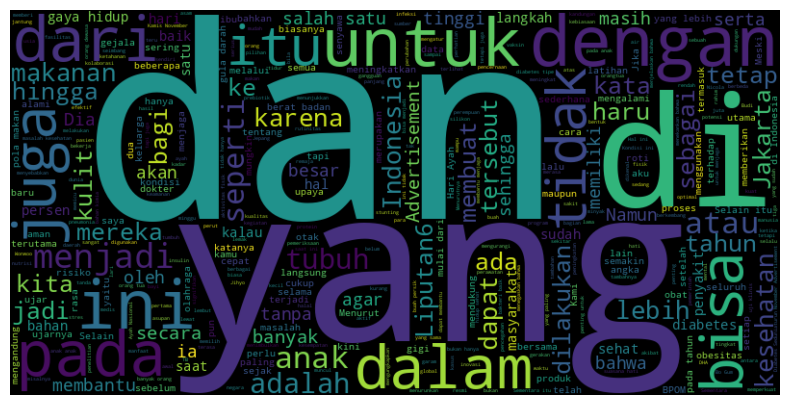

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt


# Mengisi nilai NaN dengan string kosong ('')
df['isi_artikel'] = df['isi_artikel'].fillna('')

# Menggabungkan teks dari kolom 'content'
text = ' '.join(df['isi_artikel'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp'])

wc = WordCloud(stopwords=stopwords, background_color="black", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

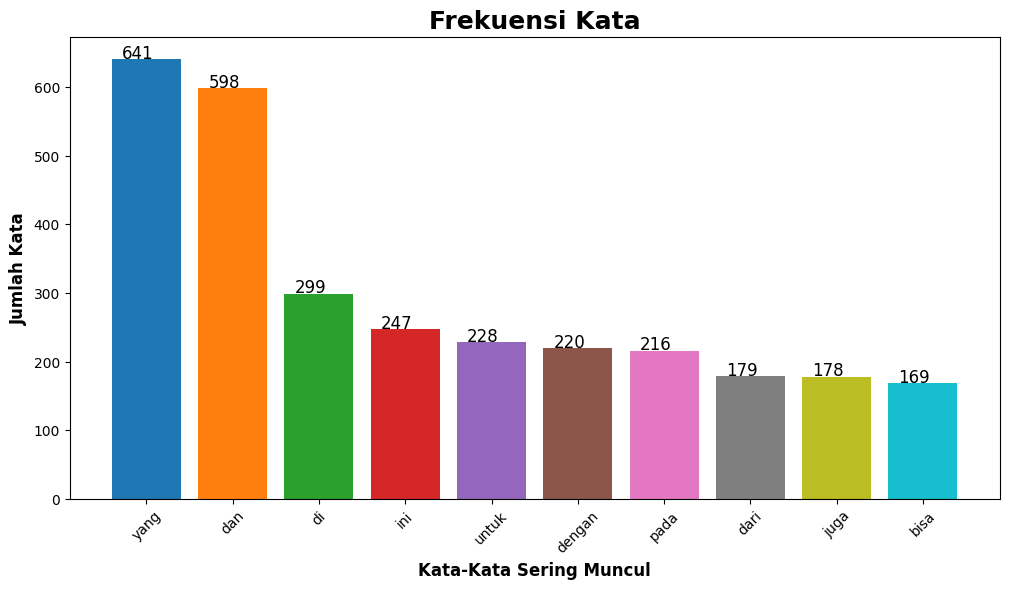

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

text = " ".join(df["isi_artikel"])

tokens = text.split()
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)

word, count = zip(*top_words)

# Definisikan palet warna
colors = plt.cm.tab10(range(len(word)))

plt.figure(figsize=(12, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')


plt.show()

**PROSES CLEANING**

---



Menghapus karakter aneh, angka, tanda baca, dan link yang tidak dibutuhkan.

In [ ]:
import re
import string
import nltk

# Fungsi untuk menghapus URL
def remove_URL(tweet):
    if tweet is not None and isinstance(tweet, str):
        url = re.compile(r'https?://\S+|www\.\S+')
        return url.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus HTML
def remove_html(tweet):
    if tweet is not None and isinstance(tweet, str):
        html = re.compile(r'<.*?>')
        return html.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus emoji
def remove_emoji(tweet):
    if tweet is not None and isinstance(tweet, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F700-\U0001F77F"  # alchemical symbols
            u"\U0001F800-\U0001F8FF"  # Geometric Shapes Extended
            u"\U0001F900-\U0001F9FF"  # Supplemental Arrows-C
            u"\U0001FA00-\U0001FA6F"  # Chess Symbols
            u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
            u"\U0001F004-\U0001F0CF"  # Additional emoticons
            u"\U0001F1E0-\U0001F1FF"  # flags
                               "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus simbol
def remove_symbols(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'[^a-zA-Z0-9\s]', '', tweet)
    return tweet

# Fungsi untuk menghapus angka
def remove_numbers(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'\d', '', tweet)
    return tweet

df['cleaning'] = df['isi_artikel'].apply(lambda x: remove_URL(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_html(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_emoji(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_symbols(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_numbers(x))

df.head(5)

,judul,tanggal,ringkasan,isi_artikel,cleaning
0,"Paramount Color Walk 2025 Siap Digelar, Ajang ...",15 Nov 2025 18:00,"Liputan6.com, TangerangAjangjalan sehatParamou...","Liputan6.com, TangerangAjangjalan sehatParamou...",Liputancom TangerangAjangjalan sehatParamount ...
1,Cara Chef Junichi Sajikan Kuliner Jepang Halal...,15 Nov 2025 16:00,"Liputan6.com, Jakarta -Mencarikuliner Jepangya...","Liputan6.com, Jakarta -Mencarikuliner Jepangya...",Liputancom Jakarta Mencarikuliner Jepangyangha...
2,"Rahasia Kulit Glowing Aktris Zhao Lusi, Andalk...",15 Nov 2025 14:00,"Liputan6.com, JakartaMasih mencari cara untuk ...","Liputan6.com, JakartaMasih mencari cara untuk ...",Liputancom JakartaMasih mencari cara untuk men...
3,"Wanmono, Sup Jepang yang Buktikan Gurih Umami ...",15 Nov 2025 12:00,"Liputan6.com, Jakarta -Dalam tradisikuliner Je...","Liputan6.com, Jakarta -Dalam tradisikuliner Je...",Liputancom Jakarta Dalam tradisikuliner Jepang...
4,"Uji Klinis Fase I Vaksin TB Inhalasi Dimulai, ...",15 Nov 2025 10:00,"Liputan6.com, Jakarta -Indonesia resmi memasuk...","Liputan6.com, Jakarta -Indonesia resmi memasuk...",Liputancom Jakarta Indonesia resmi memasuki ba...


**PROSES CASE FOLDING**

---



Mengubah semua huruf menjadi huruf kecil agar seragam (contoh: “Bagus” → “bagus”).

In [ ]:
#case_folding  digunakan untuk mengonversi teks menjadi huruf kecil (lowercase)
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
        return text

df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(5)

,judul,tanggal,ringkasan,isi_artikel,cleaning,case_folding
0,"Paramount Color Walk 2025 Siap Digelar, Ajang ...",15 Nov 2025 18:00,"Liputan6.com, TangerangAjangjalan sehatParamou...","Liputan6.com, TangerangAjangjalan sehatParamou...",Liputancom TangerangAjangjalan sehatParamount ...,liputancom tangerangajangjalan sehatparamount ...
1,Cara Chef Junichi Sajikan Kuliner Jepang Halal...,15 Nov 2025 16:00,"Liputan6.com, Jakarta -Mencarikuliner Jepangya...","Liputan6.com, Jakarta -Mencarikuliner Jepangya...",Liputancom Jakarta Mencarikuliner Jepangyangha...,liputancom jakarta mencarikuliner jepangyangha...
2,"Rahasia Kulit Glowing Aktris Zhao Lusi, Andalk...",15 Nov 2025 14:00,"Liputan6.com, JakartaMasih mencari cara untuk ...","Liputan6.com, JakartaMasih mencari cara untuk ...",Liputancom JakartaMasih mencari cara untuk men...,liputancom jakartamasih mencari cara untuk men...
3,"Wanmono, Sup Jepang yang Buktikan Gurih Umami ...",15 Nov 2025 12:00,"Liputan6.com, Jakarta -Dalam tradisikuliner Je...","Liputan6.com, Jakarta -Dalam tradisikuliner Je...",Liputancom Jakarta Dalam tradisikuliner Jepang...,liputancom jakarta dalam tradisikuliner jepang...
4,"Uji Klinis Fase I Vaksin TB Inhalasi Dimulai, ...",15 Nov 2025 10:00,"Liputan6.com, Jakarta -Indonesia resmi memasuk...","Liputan6.com, Jakarta -Indonesia resmi memasuk...",Liputancom Jakarta Indonesia resmi memasuki ba...,liputancom jakarta indonesia resmi memasuki ba...


**Normalisasi Kata**

---



Mengubah kata tidak baku menjadi kata standar (contoh: “gk” → “tidak”).

In [ ]:
import pandas as pd

# Fungsi penggantian kata tidak baku
def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]
                if isinstance(baku_word, str) and all(char.isalpha() for char in baku_word):
                    replaced_words.append(baku_word)
                    kalimat_baku.append(baku_word)
                    kata_diganti.append(word)
                    kata_tidak_baku_hash.append(hash(word))
                # else:
                #     replaced_words.append('<karakter eksplisit>')
                #     kalimat_baku.append(word)
            else:
                replaced_words.append(word)
        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ''
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash

In [ ]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d fornigulo/kamus-slag
!unzip kamus-slag.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
unzip:  cannot find or open kamus-slag.zip, kamus-slag.zip.zip or kamus-slag.zip.ZIP.


In [ ]:
# Baca dataset
data =  pd.DataFrame(df[['judul', 'tanggal', 'ringkasan', 'isi_artikel', 'cleaning','case_folding']])
data.head(5)

In [ ]:
# Baca kamus kata tidak baku
kamus_data = pd.read_excel("/content/kamuskatabaku.xlsx")
kamus_tidak_baku = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))

In [ ]:
# Terapkan fungsi penggantian kata tidak baku
df['normalisasi'], df['Kata_Baku'], df['Kata_Tidak_Baku'], df['Kata_Tidak_Baku_Hash'] = zip(*df['case_folding'].apply(lambda x: replace_taboo_words(x, kamus_tidak_baku)))

df.head(5)

,judul,tanggal,ringkasan,isi_artikel,cleaning,case_folding,normalisasi,Kata_Baku,Kata_Tidak_Baku,Kata_Tidak_Baku_Hash
0,"Paramount Color Walk 2025 Siap Digelar, Ajang ...",15 Nov 2025 18:00,"Liputan6.com, TangerangAjangjalan sehatParamou...","Liputan6.com, TangerangAjangjalan sehatParamou...",Liputancom TangerangAjangjalan sehatParamount ...,liputancom tangerangajangjalan sehatparamount ...,liputancom tangerangajangjalan sehatparamount ...,[],[],[]
1,Cara Chef Junichi Sajikan Kuliner Jepang Halal...,15 Nov 2025 16:00,"Liputan6.com, Jakarta -Mencarikuliner Jepangya...","Liputan6.com, Jakarta -Mencarikuliner Jepangya...",Liputancom Jakarta Mencarikuliner Jepangyangha...,liputancom jakarta mencarikuliner jepangyangha...,liputancom jakarta mencarikuliner jepangyangha...,[],[],[]
2,"Rahasia Kulit Glowing Aktris Zhao Lusi, Andalk...",15 Nov 2025 14:00,"Liputan6.com, JakartaMasih mencari cara untuk ...","Liputan6.com, JakartaMasih mencari cara untuk ...",Liputancom JakartaMasih mencari cara untuk men...,liputancom jakartamasih mencari cara untuk men...,liputancom jakartamasih mencari cara untuk men...,[],[],[]
3,"Wanmono, Sup Jepang yang Buktikan Gurih Umami ...",15 Nov 2025 12:00,"Liputan6.com, Jakarta -Dalam tradisikuliner Je...","Liputan6.com, Jakarta -Dalam tradisikuliner Je...",Liputancom Jakarta Dalam tradisikuliner Jepang...,liputancom jakarta dalam tradisikuliner jepang...,liputancom jakarta dalam tradisikuliner jepang...,"[kayak, kayak]","[kaya, kaya]","[-8303778956710576499, -8303778956710576499]"
4,"Uji Klinis Fase I Vaksin TB Inhalasi Dimulai, ...",15 Nov 2025 10:00,"Liputan6.com, Jakarta -Indonesia resmi memasuk...","Liputan6.com, Jakarta -Indonesia resmi memasuk...",Liputancom Jakarta Indonesia resmi memasuki ba...,liputancom jakarta indonesia resmi memasuki ba...,liputancom jakarta indonesia resmi memasuki ba...,"[dari, dari, dari, ini, ini, dari, yuk]","[dr, dr, dr, in, in, dr, yu]","[-7822831990638134, -7822831990638134, -782283..."


**TOKENIZATION**

---



Memecah kalimat menjadi potongan kata (token).

In [ ]:
#Fungsi tokenize digunakan untuk memecah teks menjadi kata-kata (token).
def tokenize(text): #text.split(): Memisahkan teks berdasarkan spasi dan mengembalikannya dalam bentuk list.
    tokens = text.split()
    return tokens

df['tokenize'] = df['normalisasi'].apply(tokenize)

df.head(5)

,judul,tanggal,ringkasan,isi_artikel,cleaning,case_folding,normalisasi,Kata_Baku,Kata_Tidak_Baku,Kata_Tidak_Baku_Hash,tokenize
0,"Paramount Color Walk 2025 Siap Digelar, Ajang ...",15 Nov 2025 18:00,"Liputan6.com, TangerangAjangjalan sehatParamou...","Liputan6.com, TangerangAjangjalan sehatParamou...",Liputancom TangerangAjangjalan sehatParamount ...,liputancom tangerangajangjalan sehatparamount ...,liputancom tangerangajangjalan sehatparamount ...,[],[],[],"[liputancom, tangerangajangjalan, sehatparamou..."
1,Cara Chef Junichi Sajikan Kuliner Jepang Halal...,15 Nov 2025 16:00,"Liputan6.com, Jakarta -Mencarikuliner Jepangya...","Liputan6.com, Jakarta -Mencarikuliner Jepangya...",Liputancom Jakarta Mencarikuliner Jepangyangha...,liputancom jakarta mencarikuliner jepangyangha...,liputancom jakarta mencarikuliner jepangyangha...,[],[],[],"[liputancom, jakarta, mencarikuliner, jepangya..."
2,"Rahasia Kulit Glowing Aktris Zhao Lusi, Andalk...",15 Nov 2025 14:00,"Liputan6.com, JakartaMasih mencari cara untuk ...","Liputan6.com, JakartaMasih mencari cara untuk ...",Liputancom JakartaMasih mencari cara untuk men...,liputancom jakartamasih mencari cara untuk men...,liputancom jakartamasih mencari cara untuk men...,[],[],[],"[liputancom, jakartamasih, mencari, cara, untu..."
3,"Wanmono, Sup Jepang yang Buktikan Gurih Umami ...",15 Nov 2025 12:00,"Liputan6.com, Jakarta -Dalam tradisikuliner Je...","Liputan6.com, Jakarta -Dalam tradisikuliner Je...",Liputancom Jakarta Dalam tradisikuliner Jepang...,liputancom jakarta dalam tradisikuliner jepang...,liputancom jakarta dalam tradisikuliner jepang...,"[kayak, kayak]","[kaya, kaya]","[-8303778956710576499, -8303778956710576499]","[liputancom, jakarta, dalam, tradisikuliner, j..."
4,"Uji Klinis Fase I Vaksin TB Inhalasi Dimulai, ...",15 Nov 2025 10:00,"Liputan6.com, Jakarta -Indonesia resmi memasuk...","Liputan6.com, Jakarta -Indonesia resmi memasuk...",Liputancom Jakarta Indonesia resmi memasuki ba...,liputancom jakarta indonesia resmi memasuki ba...,liputancom jakarta indonesia resmi memasuki ba...,"[dari, dari, dari, ini, ini, dari, yuk]","[dr, dr, dr, in, in, dr, yu]","[-7822831990638134, -7822831990638134, -782283...","[liputancom, jakarta, indonesia, resmi, memasu..."


**PROSES STOPWORD REMOVAL**

---



Menghapus kata umum yang tidak memiliki makna penting (seperti “dan”, “yang”, “di”).

In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def remove_stopwords(text):
    return [word for word in text if word not in stop_words]
df['stopword removal'] = df['tokenize'].apply(lambda x: remove_stopwords(x))
df.head(5)

,judul,tanggal,ringkasan,isi_artikel,cleaning,case_folding,normalisasi,Kata_Baku,Kata_Tidak_Baku,Kata_Tidak_Baku_Hash,tokenize,stopword removal
0,"Paramount Color Walk 2025 Siap Digelar, Ajang ...",15 Nov 2025 18:00,"Liputan6.com, TangerangAjangjalan sehatParamou...","Liputan6.com, TangerangAjangjalan sehatParamou...",Liputancom TangerangAjangjalan sehatParamount ...,liputancom tangerangajangjalan sehatparamount ...,liputancom tangerangajangjalan sehatparamount ...,[],[],[],"[liputancom, tangerangajangjalan, sehatparamou...","[liputancom, tangerangajangjalan, sehatparamou..."
1,Cara Chef Junichi Sajikan Kuliner Jepang Halal...,15 Nov 2025 16:00,"Liputan6.com, Jakarta -Mencarikuliner Jepangya...","Liputan6.com, Jakarta -Mencarikuliner Jepangya...",Liputancom Jakarta Mencarikuliner Jepangyangha...,liputancom jakarta mencarikuliner jepangyangha...,liputancom jakarta mencarikuliner jepangyangha...,[],[],[],"[liputancom, jakarta, mencarikuliner, jepangya...","[liputancom, jakarta, mencarikuliner, jepangya..."
2,"Rahasia Kulit Glowing Aktris Zhao Lusi, Andalk...",15 Nov 2025 14:00,"Liputan6.com, JakartaMasih mencari cara untuk ...","Liputan6.com, JakartaMasih mencari cara untuk ...",Liputancom JakartaMasih mencari cara untuk men...,liputancom jakartamasih mencari cara untuk men...,liputancom jakartamasih mencari cara untuk men...,[],[],[],"[liputancom, jakartamasih, mencari, cara, untu...","[liputancom, jakartamasih, mencari, kulit, lem..."
3,"Wanmono, Sup Jepang yang Buktikan Gurih Umami ...",15 Nov 2025 12:00,"Liputan6.com, Jakarta -Dalam tradisikuliner Je...","Liputan6.com, Jakarta -Dalam tradisikuliner Je...",Liputancom Jakarta Dalam tradisikuliner Jepang...,liputancom jakarta dalam tradisikuliner jepang...,liputancom jakarta dalam tradisikuliner jepang...,"[kayak, kayak]","[kaya, kaya]","[-8303778956710576499, -8303778956710576499]","[liputancom, jakarta, dalam, tradisikuliner, j...","[liputancom, jakarta, tradisikuliner, jepang, ..."
4,"Uji Klinis Fase I Vaksin TB Inhalasi Dimulai, ...",15 Nov 2025 10:00,"Liputan6.com, Jakarta -Indonesia resmi memasuk...","Liputan6.com, Jakarta -Indonesia resmi memasuk...",Liputancom Jakarta Indonesia resmi memasuki ba...,liputancom jakarta indonesia resmi memasuki ba...,liputancom jakarta indonesia resmi memasuki ba...,"[dari, dari, dari, ini, ini, dari, yuk]","[dr, dr, dr, in, in, dr, yu]","[-7822831990638134, -7822831990638134, -782283...","[liputancom, jakarta, indonesia, resmi, memasu...","[liputancom, jakarta, indonesia, resmi, memasu..."


**PROSES STEAMING DATA**

Stemming, yaitu proses mengubah kata berimbuhan menjadi bentuk dasarnya (akar kata) dalam Natural Language Processing (NLP).



In [ ]:
#Sastrawi adalah pustaka NLP khusus untuk stemming bahasa Indonesia.
!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from tqdm import tqdm

tqdm.pandas()  # Aktifkan progress bar

factory = StemmerFactory()
stemmer = factory.create_stemmer()

df['stemming_data'] = df['stopword removal'].progress_apply(
    lambda x: stemmer.stem(' '.join(x)) if isinstance(x, list) else stemmer.stem(str(x))
)

100%|██████████| 59/59 [04:40<00:00,  4.76s/it]


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 59 entries, 0 to 58
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   judul                 59 non-null     object
 1   tanggal               59 non-null     object
 2   ringkasan             59 non-null     object
 3   isi_artikel           59 non-null     object
 4   cleaning              59 non-null     object
 5   case_folding          59 non-null     object
 6   normalisasi           59 non-null     object
 7   Kata_Baku             59 non-null     object
 8   Kata_Tidak_Baku       59 non-null     object
 9   Kata_Tidak_Baku_Hash  59 non-null     object
 10  tokenize              59 non-null     object
 11  stopword removal      59 non-null     object
 12  stemming_data         59 non-null     object
dtypes: object(13)
memory usage: 8.5+ KB


**WORDCLOUD SETELAH PREPROCESSING**

---



Menampilkan kembali kata paling sering setelah pembersihan, sehingga terlihat lebih relevan dengan konteks analisis.

Kolom tersedia: ['judul', 'tanggal', 'ringkasan', 'isi_artikel', 'cleaning', 'case_folding', 'normalisasi', 'Kata_Baku', 'Kata_Tidak_Baku', 'Kata_Tidak_Baku_Hash', 'tokenize', 'stopword removal', 'stemming_data']


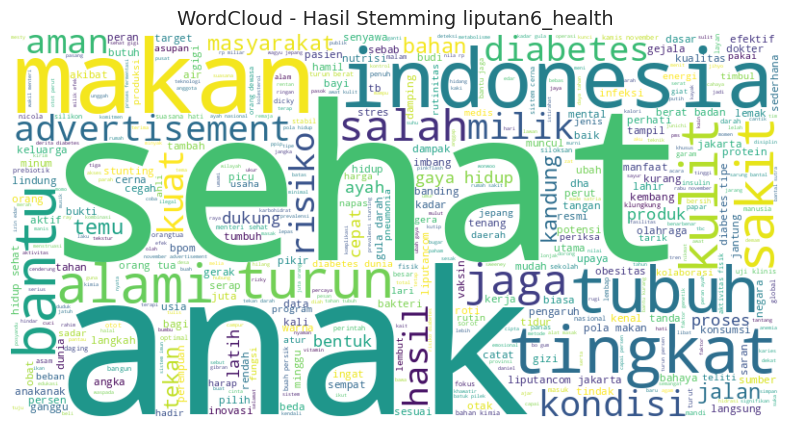

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Pastikan kolom 'stemming_data' ada
print("Kolom tersedia:", df.columns.tolist())

# Gabungkan teks dari kolom 'stemming_data'
text = ' '.join(df['stemming_data'].astype(str).tolist())

# Stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp','lu','deh','fyp', 'ya', 'gue', 'sih'])

# Buat WordCloud
wc = WordCloud(
    stopwords=stopwords,
    background_color="white",
    max_words=500,
    width=800,
    height=400
).generate(text)

# Tampilkan WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud - Hasil Stemming liputan6_health", fontsize=14)
plt.show()


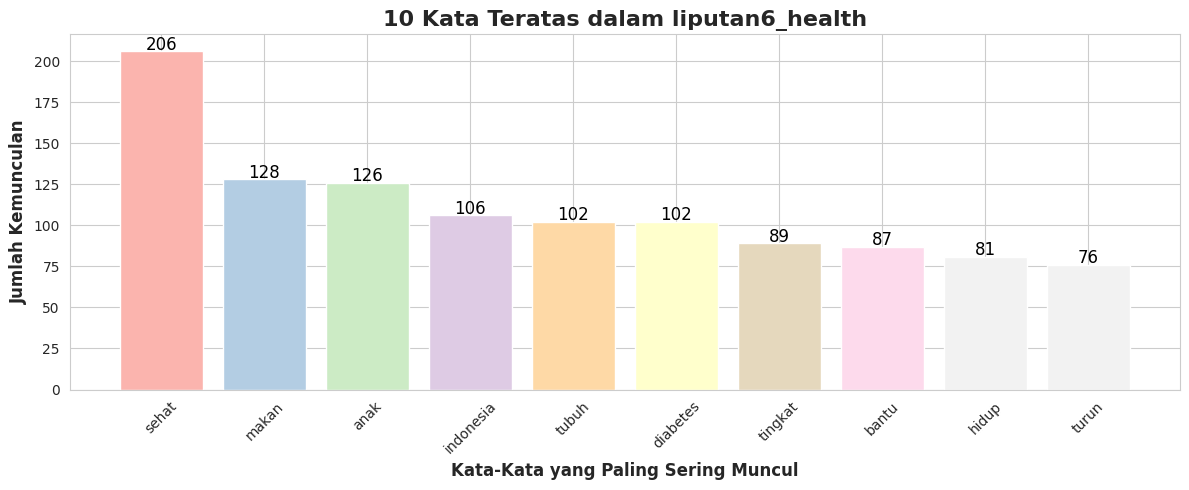

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

# Gabungkan semua teks hasil stemming
text = " ".join(df["stemming_data"].astype(str))

# Daftar stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu', 'deh', 'fyp', 'ya', 'gue', 'sih'])

# Tokenisasi dan buang stopword
tokens = [word for word in text.split() if word not in stopwords]

# Hitung frekuensi kata
word_counts = Counter(tokens)

# Ambil 10 kata paling sering muncul
top_words = word_counts.most_common(10)
word, count = zip(*top_words)

# Warna lembut dari palet Pastel
colors = plt.cm.Pastel1(range(len(word)))

# Membuat bar chart
plt.figure(figsize=(12, 5))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata yang Paling Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kemunculan", fontsize=12, fontweight='bold')
plt.title("10 Kata Teratas dalam liputan6_health", fontsize=16, fontweight='bold')
plt.xticks(rotation=45)

# Tambahkan angka di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        num + 1,
        str(num),
        fontsize=12,
        color='black',
        ha='center'
    )

# Tampilkan hasil
plt.tight_layout()
plt.show()


In [ ]:
df.to_csv('Hasil_Preprocessing_liputan6_health.csv',encoding='utf8', index=False);

# ***PELEBALAN DATA METODE LAXICON BASED***

In [ ]:
import pandas as pd

data = pd.read_csv("Hasil_Preprocessing_liputan6_health.csv")
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   judul                 59 non-null     object
 1   tanggal               59 non-null     object
 2   ringkasan             59 non-null     object
 3   isi_artikel           59 non-null     object
 4   cleaning              59 non-null     object
 5   case_folding          59 non-null     object
 6   normalisasi           59 non-null     object
 7   Kata_Baku             59 non-null     object
 8   Kata_Tidak_Baku       59 non-null     object
 9   Kata_Tidak_Baku_Hash  59 non-null     object
 10  tokenize              59 non-null     object
 11  stopword removal      59 non-null     object
 12  stemming_data         59 non-null     object
dtypes: object(13)
memory usage: 6.1+ KB


,judul,tanggal,ringkasan,isi_artikel,cleaning,case_folding,normalisasi,Kata_Baku,Kata_Tidak_Baku,Kata_Tidak_Baku_Hash,tokenize,stopword removal,stemming_data
0,"Paramount Color Walk 2025 Siap Digelar, Ajang ...",15 Nov 2025 18:00,"Liputan6.com, TangerangAjangjalan sehatParamou...","Liputan6.com, TangerangAjangjalan sehatParamou...",Liputancom TangerangAjangjalan sehatParamount ...,liputancom tangerangajangjalan sehatparamount ...,liputancom tangerangajangjalan sehatparamount ...,[],[],[],"['liputancom', 'tangerangajangjalan', 'sehatpa...","['liputancom', 'tangerangajangjalan', 'sehatpa...",liputancom tangerangajangjalan sehatparamount ...
1,Cara Chef Junichi Sajikan Kuliner Jepang Halal...,15 Nov 2025 16:00,"Liputan6.com, Jakarta -Mencarikuliner Jepangya...","Liputan6.com, Jakarta -Mencarikuliner Jepangya...",Liputancom Jakarta Mencarikuliner Jepangyangha...,liputancom jakarta mencarikuliner jepangyangha...,liputancom jakarta mencarikuliner jepangyangha...,[],[],[],"['liputancom', 'jakarta', 'mencarikuliner', 'j...","['liputancom', 'jakarta', 'mencarikuliner', 'j...",liputancom jakarta mencarikuliner jepangyangha...
2,"Rahasia Kulit Glowing Aktris Zhao Lusi, Andalk...",15 Nov 2025 14:00,"Liputan6.com, JakartaMasih mencari cara untuk ...","Liputan6.com, JakartaMasih mencari cara untuk ...",Liputancom JakartaMasih mencari cara untuk men...,liputancom jakartamasih mencari cara untuk men...,liputancom jakartamasih mencari cara untuk men...,[],[],[],"['liputancom', 'jakartamasih', 'mencari', 'car...","['liputancom', 'jakartamasih', 'mencari', 'kul...",liputancom jakartamasih cari kulit lembut dang...
3,"Wanmono, Sup Jepang yang Buktikan Gurih Umami ...",15 Nov 2025 12:00,"Liputan6.com, Jakarta -Dalam tradisikuliner Je...","Liputan6.com, Jakarta -Dalam tradisikuliner Je...",Liputancom Jakarta Dalam tradisikuliner Jepang...,liputancom jakarta dalam tradisikuliner jepang...,liputancom jakarta dalam tradisikuliner jepang...,"['kayak', 'kayak']","['kaya', 'kaya']","[-8303778956710576499, -8303778956710576499]","['liputancom', 'jakarta', 'dalam', 'tradisikul...","['liputancom', 'jakarta', 'tradisikuliner', 'j...",liputancom jakarta tradisikuliner jepang gurih...
4,"Uji Klinis Fase I Vaksin TB Inhalasi Dimulai, ...",15 Nov 2025 10:00,"Liputan6.com, Jakarta -Indonesia resmi memasuk...","Liputan6.com, Jakarta -Indonesia resmi memasuk...",Liputancom Jakarta Indonesia resmi memasuki ba...,liputancom jakarta indonesia resmi memasuki ba...,liputancom jakarta indonesia resmi memasuki ba...,"['dari', 'dari', 'dari', 'ini', 'ini', 'dari',...","['dr', 'dr', 'dr', 'in', 'in', 'dr', 'yu']","[-7822831990638134, -7822831990638134, -782283...","['liputancom', 'jakarta', 'indonesia', 'resmi'...","['liputancom', 'jakarta', 'indonesia', 'resmi'...",liputancom jakarta indonesia resmi pasuk babak...


In [ ]:
expected_cols = ['Date', 'Username', 'Rating', 'stemming_data']
available_cols = [c for c in expected_cols if c in data.columns]

data = data[available_cols]
data.head(5)


,stemming_data
0,liputancom tangerangajangjalan sehatparamount ...
1,liputancom jakarta mencarikuliner jepangyangha...
2,liputancom jakartamasih cari kulit lembut dang...
3,liputancom jakarta tradisikuliner jepang gurih...
4,liputancom jakarta indonesia resmi pasuk babak...


In [ ]:
import pandas as pd
import requests

# Unduh kamus leksikon positif dan negatif dari GitHub
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep="\t", header=None)[0])

# Fungsi untuk menentukan sentimen dan menghitung skornya
def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count
        if sentiment_score > 0:
            sentiment = "Positif"
        elif sentiment_score < 0:
            sentiment = "Negatif"
        else:
            sentiment = "Netral"
        return sentiment_score, sentiment
    return 0, "Netral"

# Gunakan kolom yang benar: 'stemming_data'
data[['Score', 'Sentiment']] = data['stemming_data'].apply(lambda x: pd.Series(determine_sentiment(x)))

# Tampilkan hasil
data.head(5)


,stemming_data,Score,Sentiment
0,liputancom tangerangajangjalan sehatparamount ...,17,Positif
1,liputancom jakarta mencarikuliner jepangyangha...,12,Positif
2,liputancom jakartamasih cari kulit lembut dang...,-6,Negatif
3,liputancom jakarta tradisikuliner jepang gurih...,12,Positif
4,liputancom jakarta indonesia resmi pasuk babak...,22,Positif


/tmp/ipython-input-1910355637.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')


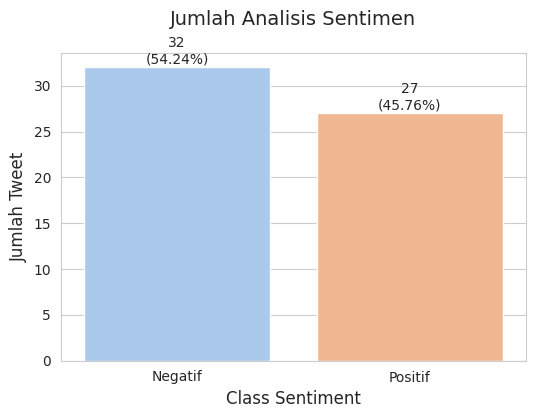

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = data['Sentiment'].value_counts()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')
plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah Tweet', fontsize=12)

total = len(data['Sentiment'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

In [ ]:
data.to_csv('Hasil_Labelling_liputan6_health.csv',encoding='utf8', index=False)

**WORDCLOUD**

---



In [ ]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling_liputan6_health.csv")
data.head(5)

,stemming_data,Score,Sentiment
0,liputancom tangerangajangjalan sehatparamount ...,17,Positif
1,liputancom jakarta mencarikuliner jepangyangha...,12,Positif
2,liputancom jakartamasih cari kulit lembut dang...,-6,Negatif
3,liputancom jakarta tradisikuliner jepang gurih...,12,Positif
4,liputancom jakarta indonesia resmi pasuk babak...,22,Positif


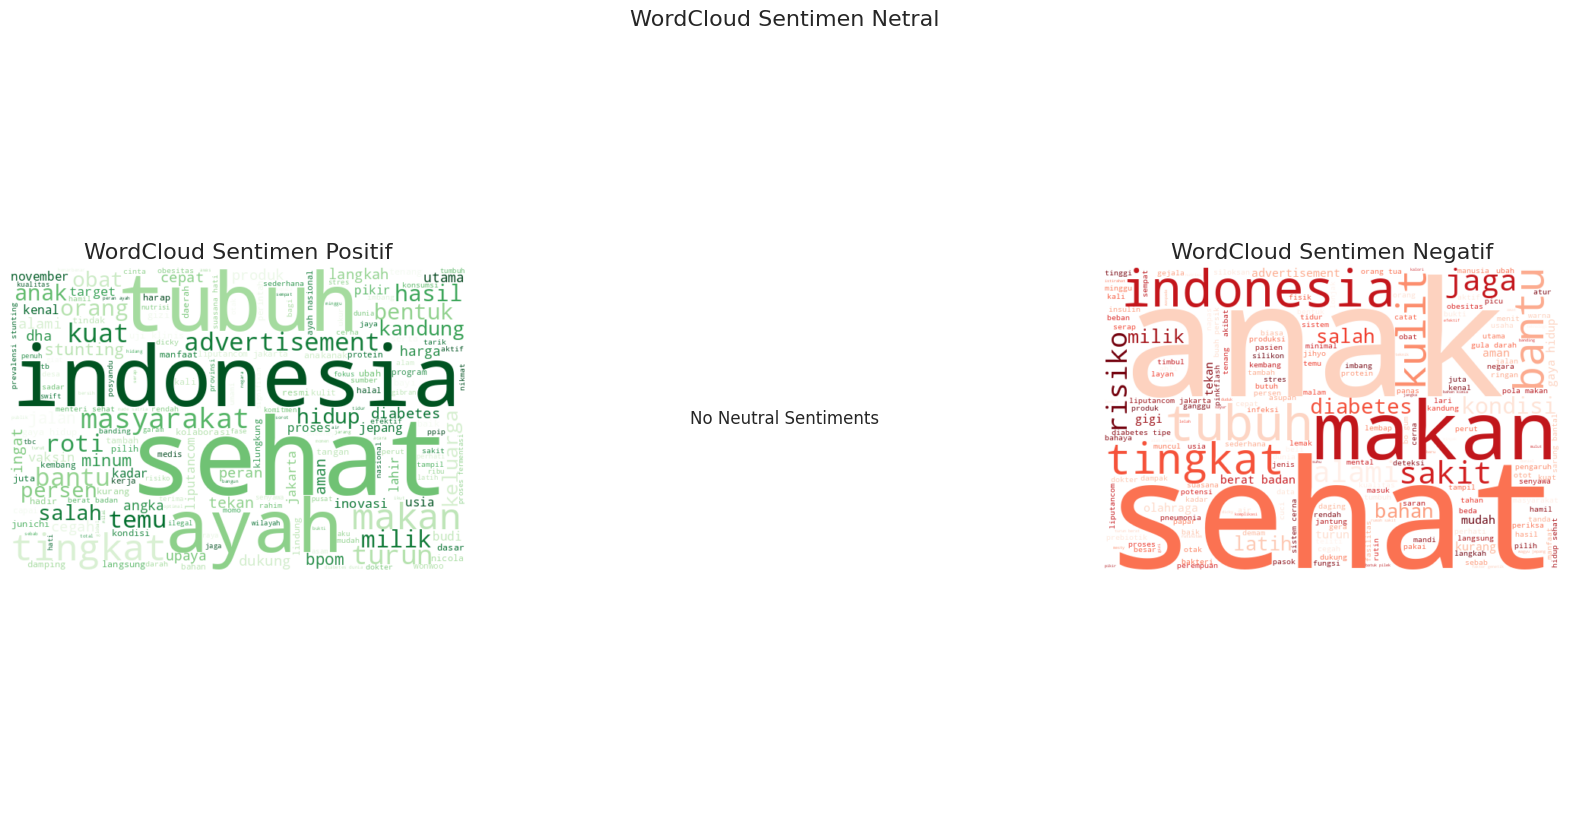

In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Pisahkan dataset berdasarkan sentimen (gunakan kolom 'stemming_data')
sentimen_Neutral = data[data['Sentiment'] == 'Netral']['stemming_data'].str.cat(sep=' ')
sentimen_Negative = data[data['Sentiment'] == 'Negatif']['stemming_data'].str.cat(sep=' ')
sentimen_Positive = data[data['Sentiment'] == 'Positif']['stemming_data'].str.cat(sep=' ')

# Membuat WordCloud untuk masing-masing sentimen
plt.figure(figsize=(20, 10))

# WordCloud Positif
plt.subplot(1, 3, 1)
wc_pos = WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(sentimen_Positive)
plt.imshow(wc_pos, interpolation='bilinear')
plt.title("WordCloud Sentimen Positif", fontsize=16)
plt.axis('off')

# WordCloud Netral
plt.subplot(1, 3, 2)
if sentimen_Neutral:
    wc_neu = WordCloud(width=600, height=400, background_color='white', colormap='Blues').generate(sentimen_Neutral)
    plt.imshow(wc_neu, interpolation='bilinear')
    plt.title("WordCloud Sentimen Netral", fontsize=16)
else:
    plt.text(0.5, 0.5, "No Neutral Sentiments", ha='center', va='center', fontsize=12)
    plt.title("WordCloud Sentimen Netral", fontsize=16)
plt.axis('off')

# WordCloud Negatif
plt.subplot(1, 3, 3)
wc_neg = WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(sentimen_Negative)
plt.imshow(wc_neg, interpolation='bilinear')
plt.title("WordCloud Sentimen Negatif", fontsize=16)
plt.axis('off')

plt.show()

# ***RANTING***

In [ ]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling_liputan6_health.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   stemming_data  59 non-null     object
 1   Score          59 non-null     int64 
 2   Sentiment      59 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.5+ KB


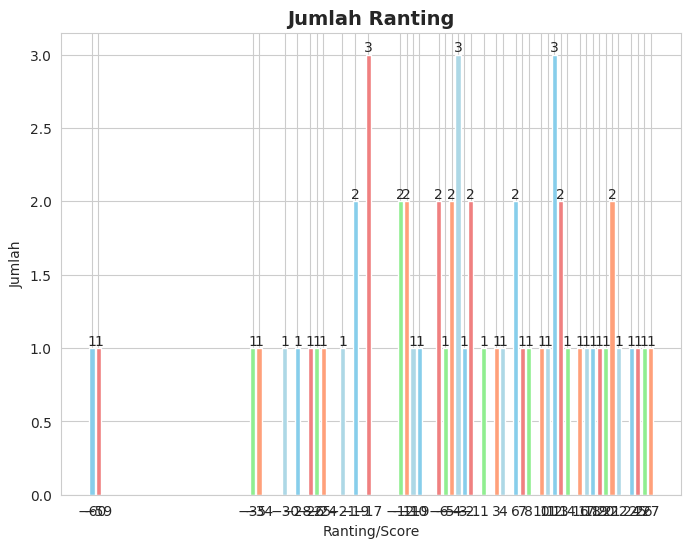

In [ ]:
import matplotlib.pyplot as plt

rating_counts = data['Score'].value_counts()
rating_counts = rating_counts.sort_index()

colors = ['skyblue', 'lightcoral', 'lightgreen', 'lightsalmon', 'lightblue']

plt.figure(figsize=(8, 6))
bars = plt.bar(rating_counts.index, rating_counts.values, color=colors)
plt.title('Jumlah Ranting', fontsize=14, fontweight='bold')
plt.xlabel('Ranting/Score')
plt.ylabel('Jumlah')
plt.xticks(rating_counts.index)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, str(int(height)), ha='center', va='bottom')

plt.show()

## Interpretasi Data Hasil Analisis Sentimen dan Rating


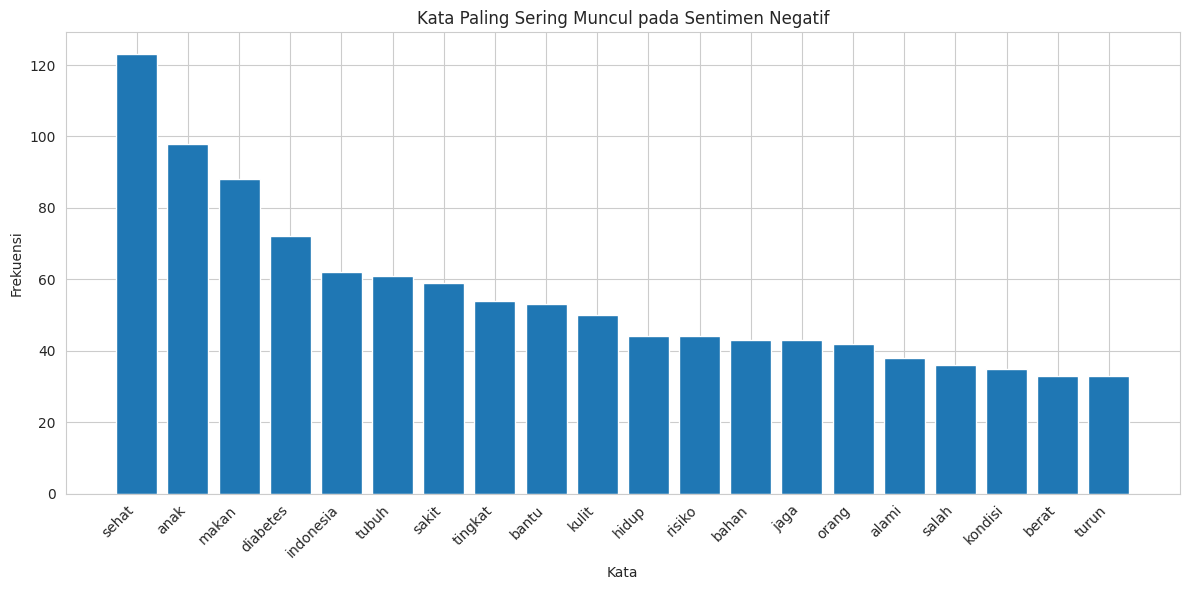

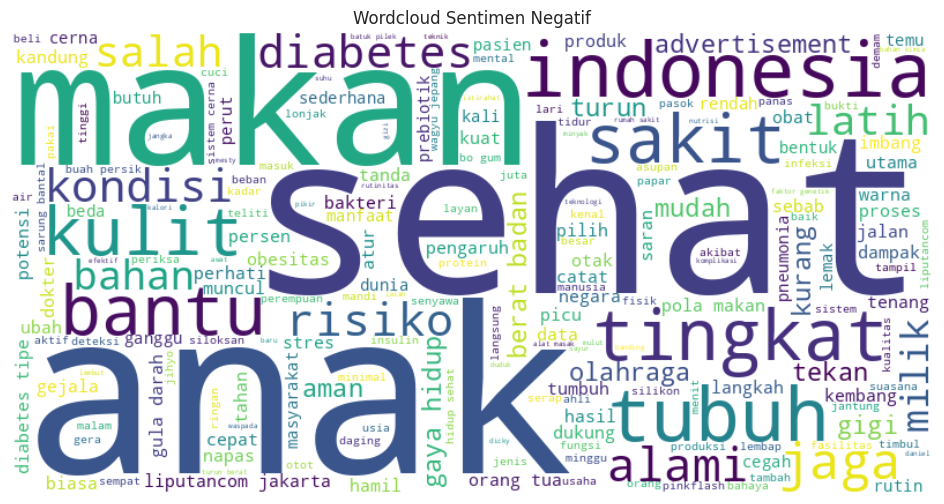

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud

# 1. Load dataset
data = pd.read_csv("Hasil_Labelling_liputan6_health.csv")

# 2. Filter hanya sentimen negatif
data_negatif = data[data['Sentiment'] == 'Negatif']

# 3. Ambil semua teks negatif yang sudah stemming
text_negatif = " ".join(data_negatif['stemming_data'].astype(str))

# 4. Hitung frekuensi kata
kata_list = text_negatif.split()
word_counts = Counter(kata_list)

# 5. Ambil 20 kata terbanyak
top_words = word_counts.most_common(20)
words, counts = zip(*top_words)

# 6. Visualisasi Bar Chart
plt.figure(figsize=(12,6))
plt.bar(words, counts)
plt.xticks(rotation=45, ha='right')
plt.title("Kata Paling Sering Muncul pada Sentimen Negatif")
plt.xlabel("Kata")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

# 7. Wordcloud khusus sentimen negatif (opsional)
wc = WordCloud(width=800, height=400, background_color='white')
plt.figure(figsize=(12,6))
plt.imshow(wc.generate(text_negatif), interpolation='bilinear')
plt.axis("off")
plt.title("Wordcloud Sentimen Negatif")
plt.show()


# **Beberapa Kalimat yg sering muncul**

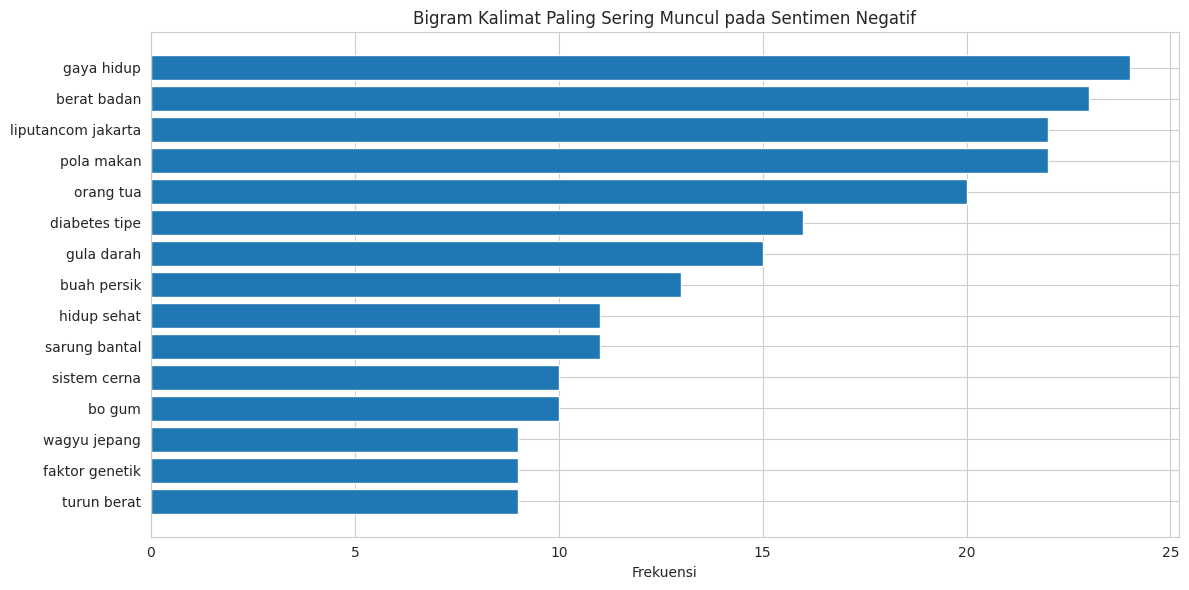

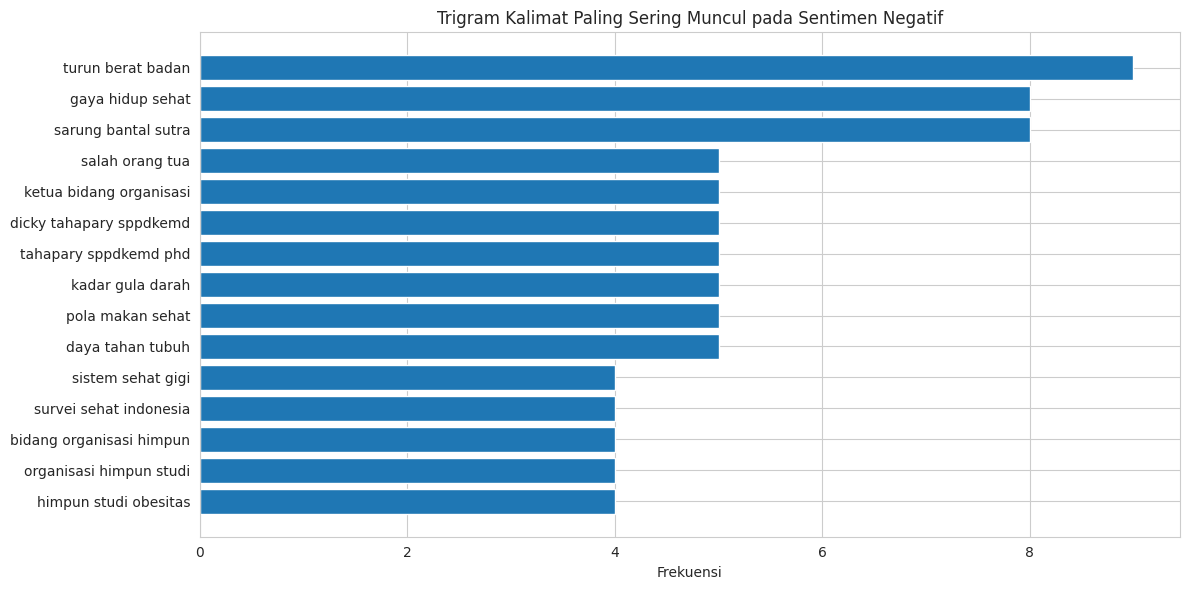

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from nltk.util import ngrams

# Load data
data = pd.read_csv("Hasil_Labelling_liputan6_health.csv")

# Filter sentimen negatif
data_negatif = data[data['Sentiment'] == 'Negatif']

# Gabungkan semua teks negatif
text_negatif = " ".join(data_negatif['stemming_data'].astype(str))

# Token list
tokens = text_negatif.split()

# Hitung Bigram dan Trigram
bigrams = list(ngrams(tokens, 2))
trigrams = list(ngrams(tokens, 3))

# Ambil 15 pola terbanyak
bigram_freq = Counter(bigrams).most_common(15)
trigram_freq = Counter(trigrams).most_common(15)

# Visualisasi Bigram
plt.figure(figsize=(12,6))
plt.barh([' '.join(bg[0]) for bg in bigram_freq], [bg[1] for bg in bigram_freq])
plt.title("Bigram Kalimat Paling Sering Muncul pada Sentimen Negatif")
plt.xlabel("Frekuensi")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Visualisasi Trigram
plt.figure(figsize=(12,6))
plt.barh([' '.join(tg[0]) for tg in trigram_freq], [tg[1] for tg in trigram_freq])
plt.title("Trigram Kalimat Paling Sering Muncul pada Sentimen Negatif")
plt.xlabel("Frekuensi")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
